# Optimal Temperature Search

Finds the Metropolis temperature for each protein family that minimizes the mean **minimum energy distance** from the natural mean.

**Method:**
- For each family, pair it as protein 1 with a dummy partner (protein 2 at T=1000, effectively unconstrained)
- Run MC simulations at candidate temperatures and track `min |E1 - nat_mean|` throughout each run
- Two-phase grid search: coarse scan over [0.5, 1.5], then fine scan around the best

**Performance:**
- JIT-compiled stripped-down MC simulation (no history/tracking overhead)
- Multiprocessing: one worker per protein family (12 families in parallel)
- Expected runtime: ~15-25 minutes on 16 cores

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys, json, time, platform
from multiprocessing import Pool, cpu_count
from tqdm.auto import tqdm

sys.path.append(os.getcwd())
import overlappingGenes as og

plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)
print(f"Platform:        {platform.system()} {platform.release()}")
print(f"Processor:       {platform.processor()}")
print(f"Python version:  {platform.python_version()}")
N_WORKERS = cpu_count()
print(f"CPU Cores:       {N_WORKERS}")
print("=" * 60)

SYSTEM INFORMATION
Platform:        Windows 11
Processor:       AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD
Python version:  3.12.12
CPU Cores:       16


c:\Users\orson\anaconda3\envs\cuda_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# === TEMPERATURE SCAN CONFIGURATION ===

# Coarse scan: wide range, moderate trials
COARSE_TEMPS = np.linspace(0.5, 1.5, 30)
N_TRIALS_COARSE = 50

# Fine scan: narrow range around best, more trials
FINE_N_TEMPS = 25
FINE_HALF_WIDTH = 0.1  # scan [best - 0.1, best + 0.1]
N_TRIALS_FINE = 50

# MC simulation parameters
MC_ITERATIONS = 250_000
OVERLAP = 60  # nucleotides (reading frame 3-0)

# Partner protein for the unconstrained side (T=1000)
DEFAULT_PARTNER = "PF00041"
FALLBACK_PARTNER = "PF00004"  # when target IS PF00041

total_per_family = len(COARSE_TEMPS) * N_TRIALS_COARSE + FINE_N_TEMPS * N_TRIALS_FINE

print("=" * 60)
print("OPTIMIZATION CONFIGURATION")
print("=" * 60)
print(f"Coarse scan:  {len(COARSE_TEMPS)} temps in [{COARSE_TEMPS[0]:.2f}, {COARSE_TEMPS[-1]:.2f}], {N_TRIALS_COARSE} trials each")
print(f"Fine scan:    {FINE_N_TEMPS} temps, +/-{FINE_HALF_WIDTH}, {N_TRIALS_FINE} trials each")
print(f"MC iters:     {MC_ITERATIONS:,} per trial")
print(f"Overlap:      {OVERLAP} nt")
print(f"Trials/family: {total_per_family:,}")
print("=" * 60)

OPTIMIZATION CONFIGURATION
Coarse scan:  30 temps in [0.50, 1.50], 50 trials each
Fine scan:    25 temps, +/-0.1, 50 trials each
MC iters:     250,000 per trial
Overlap:      60 nt
Trials/family: 2,750


In [3]:
# Load all protein families
BASE_DIR = "bmDCA"
ALL_PF = sorted([d for d in os.listdir(BASE_DIR)
                 if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith("PF")])
print(f"Found {len(ALL_PF)} protein families: {ALL_PF}\n")

family_data = {}
for pf in ALL_PF:
    param_file = os.path.join(BASE_DIR, pf, f"{pf}_params.dat")
    nat_file = os.path.join(BASE_DIR, pf, f"{pf}_naturalenergies.txt")

    J, h = og.extract_params(param_file)
    energies = og.load_natural_energies(nat_file)
    prot_len = int(len(h) / 21)

    family_data[pf] = {
        'J': J, 'h': h,
        'nat_mean': np.mean(energies),
        'nat_std': np.std(energies),
        'prot_len': prot_len,
    }
    print(f"  {pf}: {prot_len} AA, E_nat = {np.mean(energies):.2f} +/- {np.std(energies):.2f}")

# Load old temperatures for comparison
OLD_TEMPS_FILE = "optimal_temperatures.json"
OLD_TEMPS = {}
if os.path.exists(OLD_TEMPS_FILE):
    with open(OLD_TEMPS_FILE, 'r') as f:
        OLD_TEMPS = json.load(f)
    print(f"\nLoaded old temperatures from {OLD_TEMPS_FILE}")
    for pf, t in OLD_TEMPS.items():
        print(f"  {pf}: T = {t:.4f}")

Found 12 protein families: ['PF00004', 'PF00041', 'PF00072', 'PF00076', 'PF00096', 'PF00153', 'PF00271', 'PF00397', 'PF00512', 'PF00595', 'PF02518', 'PF07679']

  PF00004: 110 AA, E_nat = 145.88 +/- 38.25
  PF00041: 74 AA, E_nat = 120.66 +/- 17.64
  PF00072: 108 AA, E_nat = 201.37 +/- 29.97
  PF00076: 59 AA, E_nat = 80.85 +/- 17.50
  PF00096: 23 AA, E_nat = 16.44 +/- 5.23
  PF00153: 85 AA, E_nat = 92.55 +/- 25.62
  PF00271: 95 AA, E_nat = 149.58 +/- 27.18
  PF00397: 28 AA, E_nat = 34.45 +/- 7.29
  PF00512: 62 AA, E_nat = 105.72 +/- 17.69
  PF00595: 71 AA, E_nat = 87.53 +/- 17.89
  PF02518: 101 AA, E_nat = 186.84 +/- 26.05
  PF07679: 76 AA, E_nat = 63.66 +/- 19.08

Loaded old temperatures from optimal_temperatures.json
  PF00004: T = 0.8667
  PF00041: T = 1.0000
  PF00072: T = 1.0000
  PF00076: T = 0.8333
  PF00096: T = 0.8667
  PF00153: T = 0.8333
  PF00271: T = 0.9333
  PF00397: T = 0.8333
  PF00512: T = 0.9667
  PF00595: T = 0.8333
  PF02518: T = 1.0667
  PF07679: T = 0.9000


In [4]:
# JIT warmup and prepare worker arguments
print("Warming up JIT compilation...")
from temp_optimization_worker import mc_trial_min_distance, optimize_single_family
from overlappingGenes import seq_str_to_int_array

warmup_pf = ALL_PF[0]
warmup_partner = ALL_PF[1] if ALL_PF[0] == DEFAULT_PARTNER else DEFAULT_PARTNER
wd = family_data[warmup_pf]
wp = family_data[warmup_partner]

warmup_seq = og.initial_seq_no_stops(wd['prot_len'], wp['prot_len'], OVERLAP, quiet=True)
warmup_int = seq_str_to_int_array(warmup_seq)
_ = mc_trial_min_distance(wd['J'], wd['h'], wp['J'], wp['h'],
                          warmup_int, 1.0, 1000.0, 1000, wd['nat_mean'])
print("JIT compilation complete.\n")

# Prepare worker arguments for all families
worker_args = []
for pf in ALL_PF:
    fd = family_data[pf]
    partner = DEFAULT_PARTNER if pf != DEFAULT_PARTNER else FALLBACK_PARTNER
    pd = family_data[partner]

    worker_args.append((
        pf, fd['J'], fd['h'], fd['nat_mean'], fd['nat_std'],
        pd['J'], pd['h'], pd['prot_len'],
        OVERLAP, COARSE_TEMPS, N_TRIALS_COARSE, N_TRIALS_FINE,
        FINE_N_TEMPS, FINE_HALF_WIDTH, MC_ITERATIONS
    ))

print(f"Prepared {len(worker_args)} optimization tasks")

Warming up JIT compilation...
JIT compilation complete.

Prepared 12 optimization tasks


In [5]:
# Run temperature optimization in parallel
if __name__ == '__main__':
    n_procs = min(N_WORKERS, len(ALL_PF))
    print(f"Starting optimization: {len(ALL_PF)} families across {n_procs} workers")
    print(f"Each family: {total_per_family:,} MC trials x {MC_ITERATIONS:,} iterations")
    print(f"Estimated time: ~15-25 minutes\n")

    start_time = time.time()

    with Pool(processes=n_procs) as pool:
        results_list = []
        pbar = tqdm(total=len(ALL_PF), desc="Optimizing families", unit="family")

        for result in pool.imap_unordered(optimize_single_family, worker_args):
            elapsed = time.time() - start_time
            pbar.set_postfix({
                'last': result['pf_name'],
                'T*': f"{result['optimal_T']:.4f}",
                'elapsed': f"{elapsed:.0f}s"
            })
            pbar.update(1)
            results_list.append(result)

        pbar.close()

    total_time = time.time() - start_time
    print(f"\nDone in {total_time/60:.1f} minutes ({total_time:.0f}s)")

    # Print summary
    for r in sorted(results_list, key=lambda x: x['pf_name']):
        print(f"  {r['pf_name']}: T* = {r['optimal_T']:.4f} (min dist = {r['optimal_dist']:.2f})")

Starting optimization: 12 families across 12 workers
Each family: 2,750 MC trials x 250,000 iterations
Estimated time: ~15-25 minutes



Optimizing families: 100%|██████████| 12/12 [22:19<00:00, 111.63s/family, last=PF00041, T*=0.9733, elapsed=1340s]


Done in 22.3 minutes (1340s)
  PF00004: T* = 0.8365 (min dist = 0.00)
  PF00041: T* = 0.9733 (min dist = 0.00)
  PF00072: T* = 0.9661 (min dist = 0.00)
  PF00076: T* = 0.8543 (min dist = 0.00)
  PF00096: T* = 0.8543 (min dist = 0.00)
  PF00153: T* = 0.8175 (min dist = 0.00)
  PF00271: T* = 0.8721 (min dist = 0.00)
  PF00397: T* = 0.8532 (min dist = 0.00)
  PF00512: T* = 0.9411 (min dist = 0.00)
  PF00595: T* = 0.8187 (min dist = 0.00)
  PF02518: T* = 1.0684 (min dist = 0.00)
  PF07679: T* = 0.8615 (min dist = 0.00)


In [6]:
# Organize results and compare with old temperatures
results = {r['pf_name']: r for r in results_list}

new_temps = {}
print(f"{'Family':<10} {'Old T':>8} {'New T':>8} {'Change':>8} {'Mean MinDist':>13} {'Nat Std':>10}")
print("-" * 60)

for pf in ALL_PF:
    r = results[pf]
    old_t = OLD_TEMPS.get(pf, 1.0)
    new_t = r['optimal_T']
    new_temps[pf] = new_t
    change = new_t - old_t
    print(f"{pf:<10} {old_t:>8.4f} {new_t:>8.4f} {change:>+8.4f} {r['optimal_dist']:>13.2f} {r['nat_std']:>10.2f}")

Family        Old T    New T   Change  Mean MinDist    Nat Std
------------------------------------------------------------
PF00004      0.8667   0.8365  -0.0302          0.00      38.25
PF00041      1.0000   0.9733  -0.0267          0.00      17.64
PF00072      1.0000   0.9661  -0.0339          0.00      29.97
PF00076      0.8333   0.8543  +0.0210          0.00      17.50
PF00096      0.8667   0.8543  -0.0124          0.00       5.23
PF00153      0.8333   0.8175  -0.0158          0.00      25.62
PF00271      0.9333   0.8721  -0.0612          0.00      27.18
PF00397      0.8333   0.8532  +0.0198          0.00       7.29
PF00512      0.9667   0.9411  -0.0256          0.00      17.69
PF00595      0.8333   0.8187  -0.0147          0.00      17.89
PF02518      1.0667   1.0684  +0.0017          0.00      26.05
PF07679      0.9000   0.8615  -0.0385          0.00      19.08


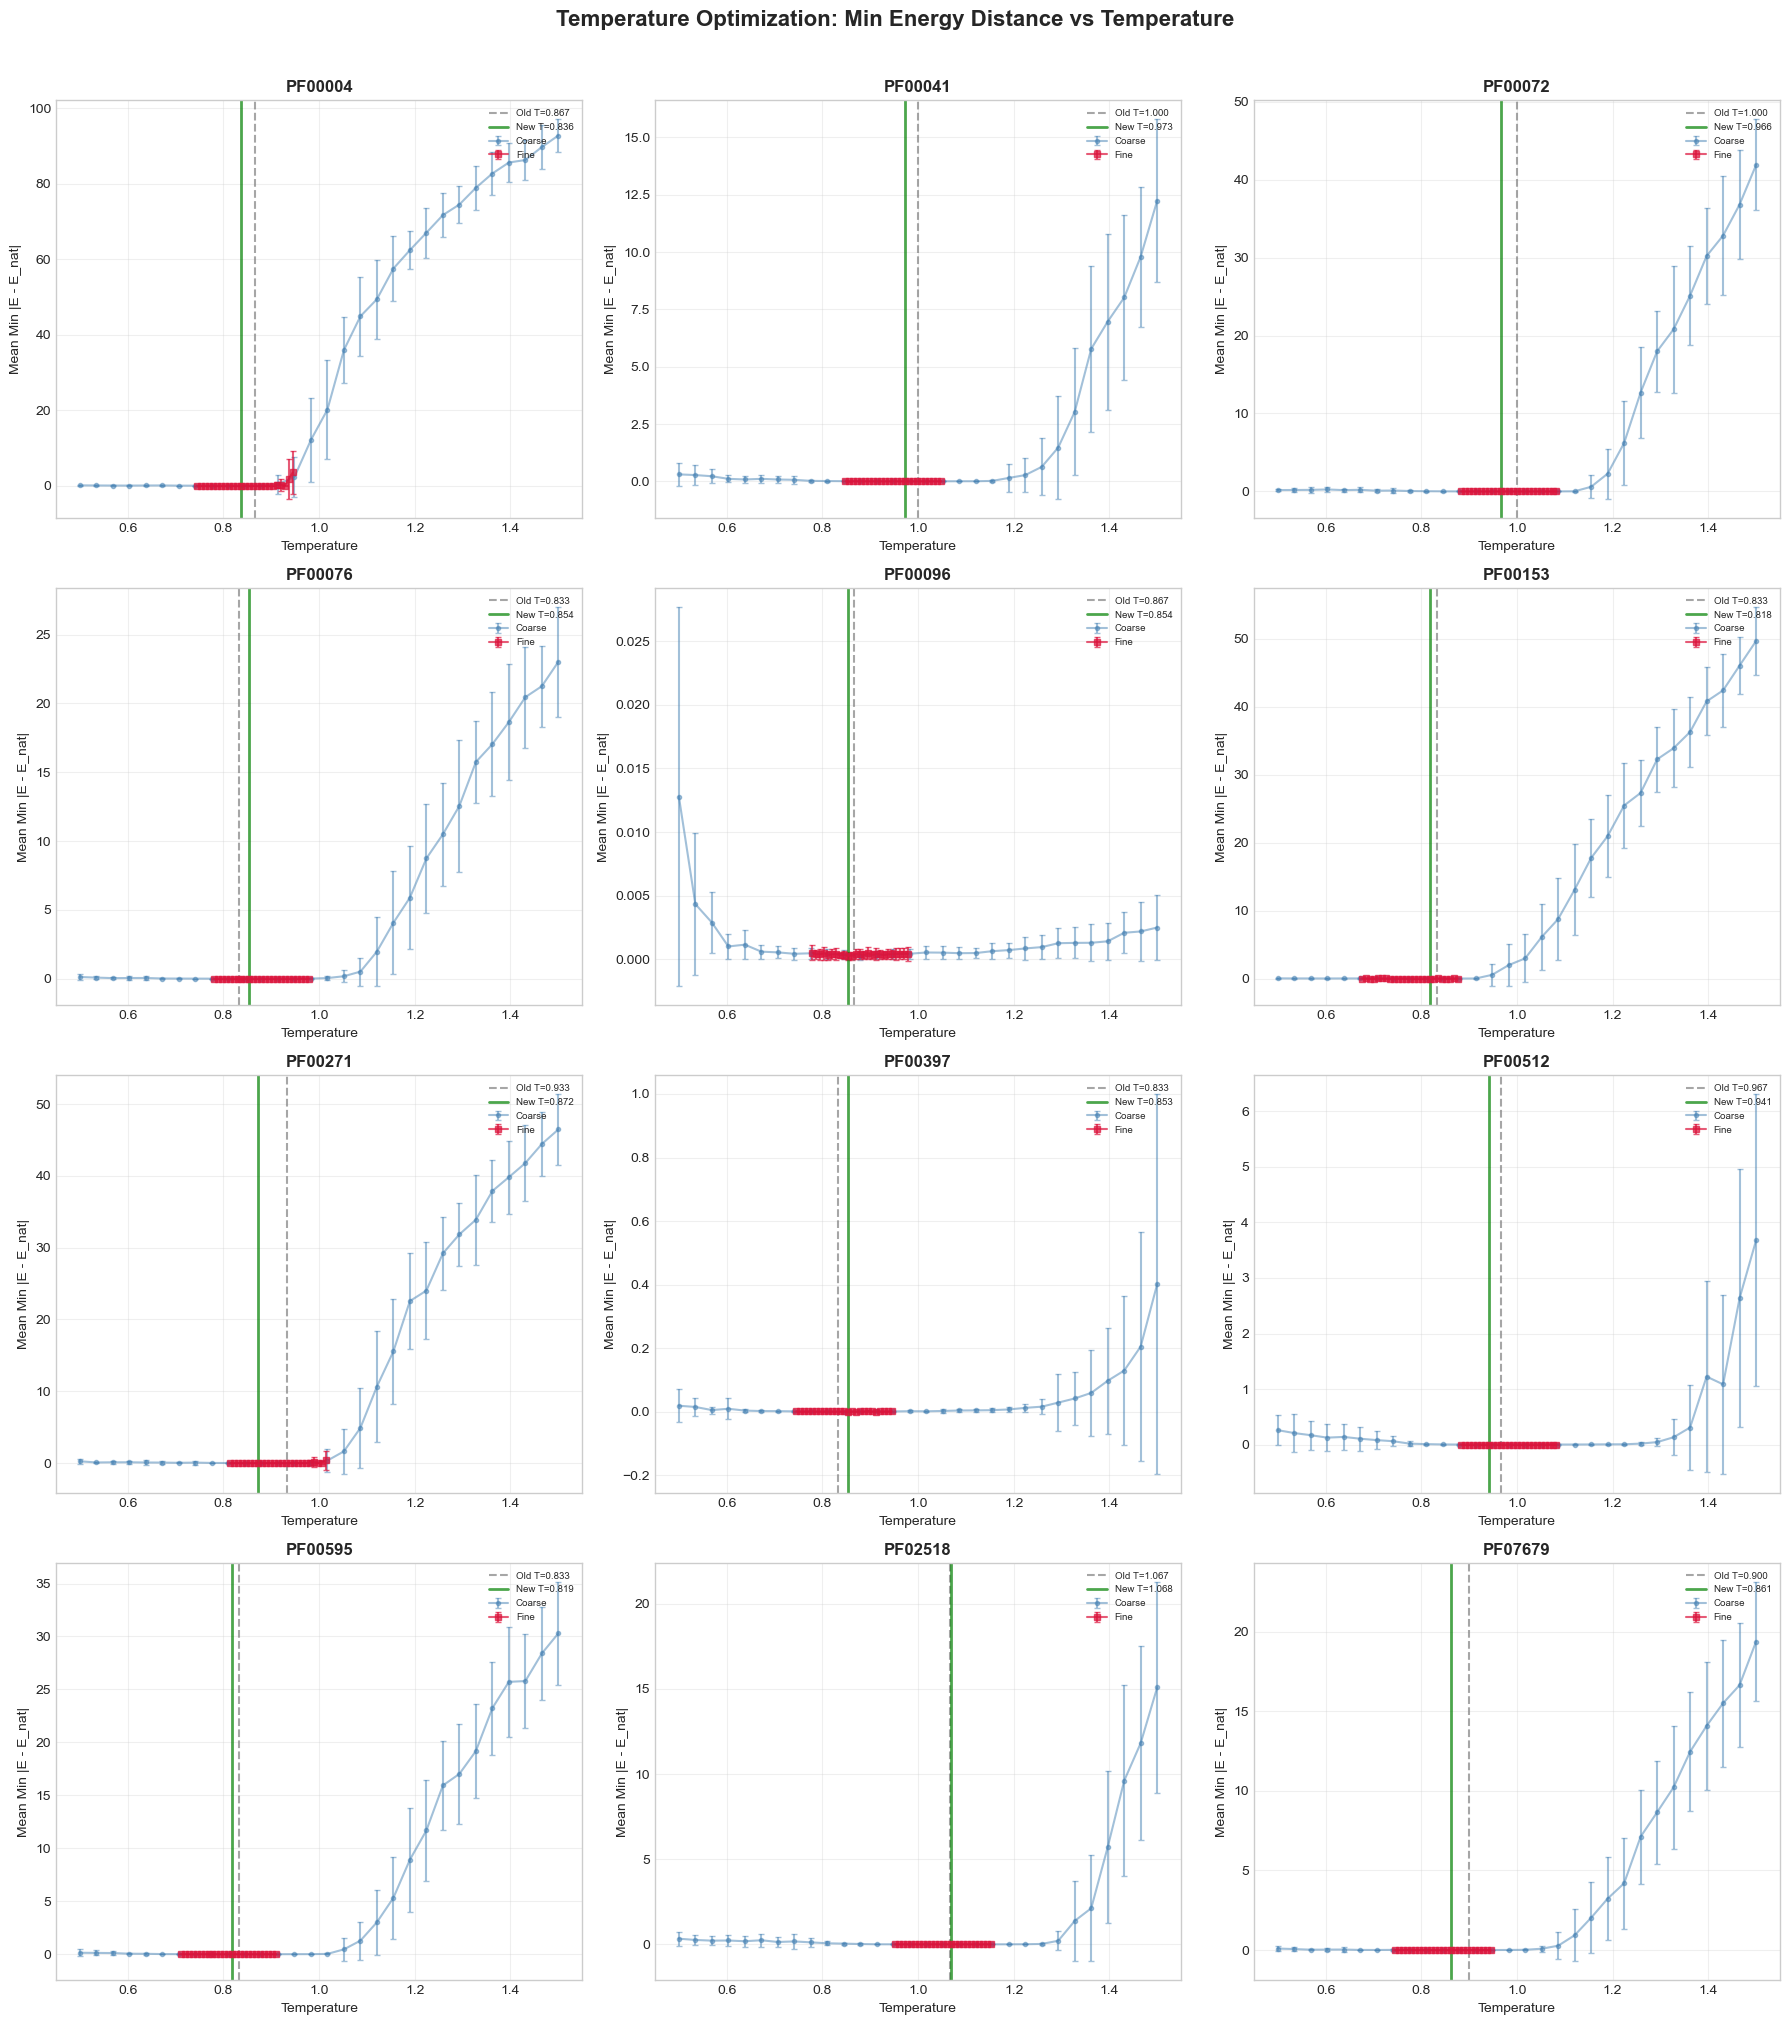

In [7]:
# Per-family optimization curves
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, pf in enumerate(ALL_PF):
    ax = axes[idx]
    r = results[pf]

    # Coarse scan
    cT = [c[0] for c in r['coarse_results']]
    cM = [c[1] for c in r['coarse_results']]
    cS = [c[2] for c in r['coarse_results']]
    ax.errorbar(cT, cM, yerr=cS, fmt='o-', color='steelblue', alpha=0.5,
                markersize=3, capsize=2, label='Coarse')

    # Fine scan
    fT = [c[0] for c in r['fine_results']]
    fM = [c[1] for c in r['fine_results']]
    fS = [c[2] for c in r['fine_results']]
    ax.errorbar(fT, fM, yerr=fS, fmt='s-', color='crimson', alpha=0.7,
                markersize=4, capsize=2, label='Fine')

    # Mark old and new optima
    old_t = OLD_TEMPS.get(pf, 1.0)
    ax.axvline(old_t, color='gray', linestyle='--', alpha=0.7,
               label=f'Old T={old_t:.3f}')
    ax.axvline(r['optimal_T'], color='green', linestyle='-', linewidth=2,
               alpha=0.7, label=f'New T={r["optimal_T"]:.3f}')

    ax.set_title(f'{pf}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Mean Min |E - E_nat|')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Temperature Optimization: Min Energy Distance vs Temperature',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('temperature_optimization_curves.png', dpi=150, bbox_inches='tight')
plt.show()

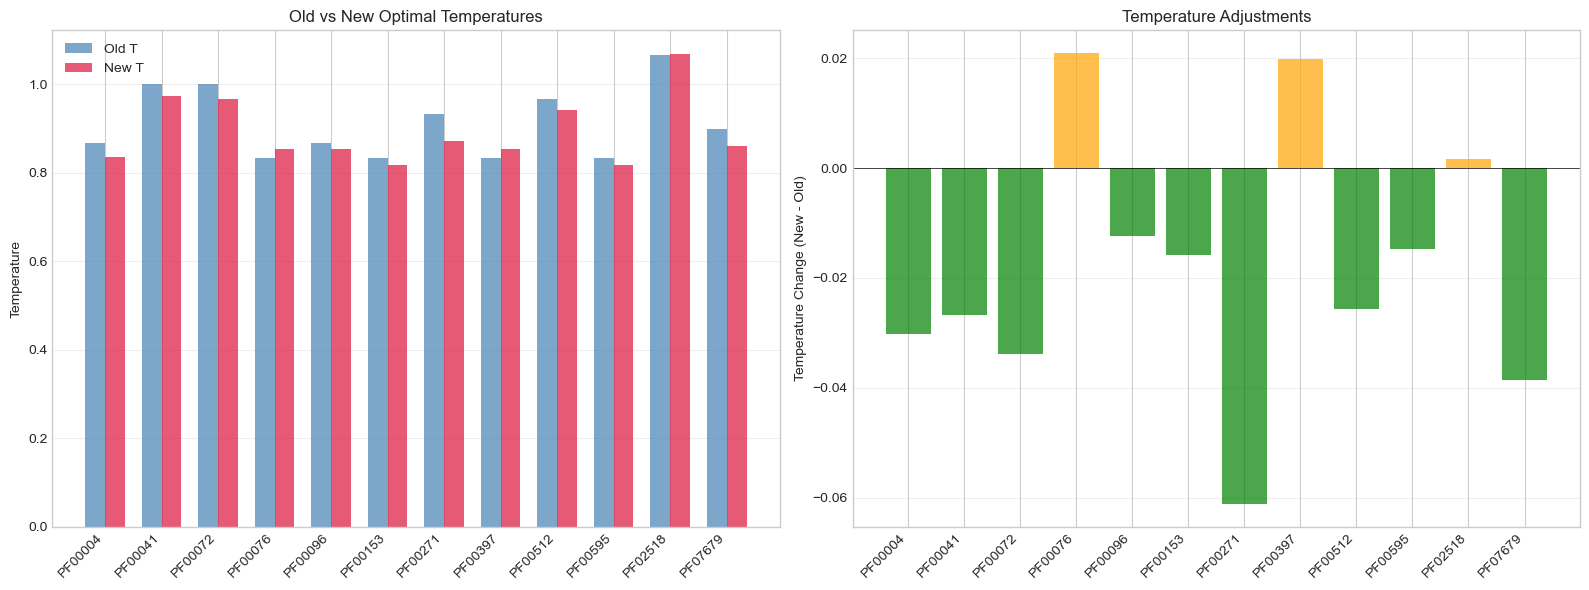

In [8]:
# Old vs New temperature comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(ALL_PF))
width = 0.35

old_vals = [OLD_TEMPS.get(pf, 1.0) for pf in ALL_PF]
new_vals = [new_temps[pf] for pf in ALL_PF]

ax1.bar(x - width/2, old_vals, width, label='Old T', color='steelblue', alpha=0.7)
ax1.bar(x + width/2, new_vals, width, label='New T', color='crimson', alpha=0.7)
ax1.set_ylabel('Temperature')
ax1.set_title('Old vs New Optimal Temperatures')
ax1.set_xticks(x)
ax1.set_xticklabels(ALL_PF, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Change chart
changes = [new_vals[i] - old_vals[i] for i in range(len(ALL_PF))]
colors = ['green' if c < 0 else 'orange' if c > 0 else 'gray' for c in changes]
ax2.bar(x, changes, color=colors, alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Temperature Change (New - Old)')
ax2.set_title('Temperature Adjustments')
ax2.set_xticks(x)
ax2.set_xticklabels(ALL_PF, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temperature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Validation: estimate min-distance at old temperature from coarse scan data
print(f"{'Family':<10} {'Old T':>8} {'MinDist@Old':>13} {'New T':>8} {'MinDist@New':>13} {'Improvement':>12}")
print("-" * 66)

for pf in ALL_PF:
    r = results[pf]
    old_t = OLD_TEMPS.get(pf, 1.0)

    # Find nearest coarse scan point to old temperature
    coarse_temps = np.array([c[0] for c in r['coarse_results']])
    coarse_dists = np.array([c[1] for c in r['coarse_results']])
    nearest_idx = np.argmin(np.abs(coarse_temps - old_t))
    old_dist_est = coarse_dists[nearest_idx]

    new_dist = r['optimal_dist']
    improvement = ((old_dist_est - new_dist) / old_dist_est * 100) if old_dist_est > 0 else 0

    print(f"{pf:<10} {old_t:>8.4f} {old_dist_est:>13.2f} "
          f"{r['optimal_T']:>8.4f} {new_dist:>13.2f} {improvement:>+11.1f}%")

Family        Old T   MinDist@Old    New T   MinDist@New  Improvement
------------------------------------------------------------------
PF00004      0.8667          0.00   0.8365          0.00       +64.9%
PF00041      1.0000          0.00   0.9733          0.00       +53.6%
PF00072      1.0000          0.00   0.9661          0.00       +13.6%
PF00076      0.8333          0.00   0.8543          0.00       +30.9%
PF00096      0.8667          0.00   0.8543          0.00        +4.7%
PF00153      0.8333          0.00   0.8175          0.00       +16.8%
PF00271      0.9333          0.00   0.8721          0.00       +40.7%
PF00397      0.8333          0.00   0.8532          0.00        +0.5%
PF00512      0.9667          0.00   0.9411          0.00       -11.8%
PF00595      0.8333          0.00   0.8187          0.00       +23.0%
PF02518      1.0667          0.00   1.0684          0.00       -14.8%
PF07679      0.9000          0.00   0.8615          0.00       +43.6%


In [10]:
# Save new optimal temperatures
output = {pf: round(new_temps[pf], 6) for pf in ALL_PF}

print("New optimal temperatures:")
print(json.dumps(output, indent=4))

# Save locally
with open("optimal_temperatures.json", 'w') as f:
    json.dump(output, f, indent=4)
print("\nSaved to optimal_temperatures.json")

# Also save to Project folder (main source of truth)
project_path = os.path.join("..", "Project", "optimal_temperatures.json")
if os.path.exists(os.path.dirname(project_path)):
    with open(project_path, 'w') as f:
        json.dump(output, f, indent=4)
    print(f"Saved to {project_path}")

# Also save to GA folder if it exists
ga_path = os.path.join("..", "GA", "optimal_temperatures.json")
if os.path.exists(os.path.dirname(ga_path)):
    with open(ga_path, 'w') as f:
        json.dump(output, f, indent=4)
    print(f"Saved to {ga_path}")

New optimal temperatures:
{
    "PF00004": 0.836494,
    "PF00041": 0.973276,
    "PF00072": 0.966092,
    "PF00076": 0.85431,
    "PF00096": 0.85431,
    "PF00153": 0.817529,
    "PF00271": 0.872126,
    "PF00397": 0.853161,
    "PF00512": 0.941092,
    "PF00595": 0.818678,
    "PF02518": 1.068391,
    "PF07679": 0.861494
}

Saved to optimal_temperatures.json
Saved to ..\Project\optimal_temperatures.json
Saved to ..\GA\optimal_temperatures.json
